# a)

Analizę zbieżności schematów iteracyjnych postaci $x_{n+1} = \phi(x_n)$ dla pierwiastka $\alpha = 2$.
Zgodnie z twierdzeniem o zbieżności lokalnej, badamy wartość modułu pierwszej pochodnej w punkcie będącym pierwiastkiem, czyli $|\phi'(2)|$:
- Jeśli $|\phi'(2)| < 1$, schemat jest zbieżny.
- Jeśli $|\phi'(2)| > 1$, schemat jest rozbieżny.
- Jeśli $\phi'(2) \neq 0$ (i zbieżny), rząd zbieżności jest liniowy.
- Jeśli $\phi'(2) = 0$, rząd zbieżności jest co najmniej kwadratowy.

## 1. Schemat $\phi_1(x) = \frac{x^2 + 2}{3}$

- **Pochodna funkcji:** $\phi_1'(x) = \frac{2x}{3}$
- **Wartość dla $\alpha = 2$:** $\phi_1'(2) = \frac{4}{3}$
- **Wniosek:** $|\phi_1'(2)| > 1$. Schemat jest **rozbieżny**.

## 2. Schemat $\phi_2(x) = \sqrt{3x - 2}$

- **Pochodna funkcji:** $\phi_2'(x) = \frac{3}{2\sqrt{3x - 2}}$
- **Wartość dla $\alpha = 2$:** $\phi_2'(2) = \frac{3}{2\sqrt{4}} = \frac{3}{4}$
- **Wniosek:** $|\phi_2'(2)| = 0.75 < 1$. Schemat jest **zbieżny**. Ponieważ wartość jest różna od zera, rząd zbieżności jest **liniowy**.

## 3. Schemat $\phi_3(x) = 3 - \frac{2}{x}$

- **Pochodna funkcji:** $\phi_3'(x) = \frac{2}{x^2}$
- **Wartość dla $\alpha = 2$:** $\phi_3'(2) = \frac{2}{4} = \frac{1}{2}$
- **Wniosek:** $|\phi_3'(2)| = 0.5 < 1$. Schemat jest **zbieżny**. Rząd zbieżności jest **liniowy**, ale szybszy niż w schemacie 2 (ponieważ $0.5 < 0.75$).

## 4. Schemat $\phi_4(x) = \frac{x^2 - 2}{2x - 3}$

- **Pochodna funkcji:** $\phi_4'(x) = \frac{2x^2 - 6x + 4}{(2x - 3)^2}$
- **Wartość dla $\alpha = 2$:** $\phi_4'(2) = \frac{8 - 12 + 4}{(4 - 3)^2} = \frac{0}{1} = 0$
- **Wniosek:** $|\phi_4'(2)| = 0 < 1$. Schemat jest **zbieżny**. Rząd zbieżności jest co najmniej **kwadratowy**.

# b)

In [23]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 2.0

In [24]:
def dphi1(x):
    return 2*x / 3
def dphi2(x):
    return 3 / (2 * np.sqrt(3*x - 2))
def dphi3(x):
    return 2 / (x**2)
def dphi4(x):
    return (2*x**2 - 6*x + 4) / ((2*x - 3)**2)

In [25]:
derivatives = [dphi1, dphi2, dphi3, dphi4]

for i, dphi in enumerate(derivatives, 1):
    val = dphi(alpha)
    abs_val = np.abs(val)
    print(f"Schemat {i}:")
    print(f"  |phi'({alpha})| = {abs_val:.4f}")
    if abs_val >= 1:
        print("  Wniosek: Rozbieżny\n")
    elif np.isclose(abs_val, 0):
        print("  Wniosek: Zbieżny (rząd co najmniej kwadratowy)\n")
    else:
        print("  Wniosek: Zbieżny (rząd liniowy)\n")

Schemat 1:
  |phi'(2.0)| = 1.3333
  Wniosek: Rozbieżny

Schemat 2:
  |phi'(2.0)| = 0.7500
  Wniosek: Zbieżny (rząd liniowy)

Schemat 3:
  |phi'(2.0)| = 0.5000
  Wniosek: Zbieżny (rząd liniowy)

Schemat 4:
  |phi'(2.0)| = 0.0000
  Wniosek: Zbieżny (rząd co najmniej kwadratowy)



In [26]:
def phi1(x):
    return (x**2 + 2) / 3
def phi2(x):
    return np.sqrt(3*x - 2)
def phi3(x):
    return 3 - 2/x
def phi4(x):
    return (x**2 - 2) / (2*x - 3)

In [27]:
funcs = [(1, phi1), (2, phi2), (3, phi3), (4, phi4)]
x_star = 2.0
x0 = 2.1 # Punkt startowy
iterations = 10

rel_errors = {}

In [28]:
for i, phi in funcs:
    print(f"--- Schemat {i} ---")
    print(f"{'k':>2} | {'Przybliżenie x_k':>16} | {'Błąd eps_k':>14} | {'Rząd r_k':>10}")
    print("-" * 53)
    
    x_vals = [x0]
    eps_vals = [np.abs(x0 - x_star)]
    
    for k in range(iterations):
        try:
            next_x = phi(x_vals[-1])
            x_vals.append(next_x)
            eps_vals.append(np.abs(next_x - x_star))
        except Exception:
            break
            
    # |x_k - x*| / |x*|
    rel_errors[i] = [e / np.abs(x_star) for e in eps_vals]
            
    for k in range(1, len(x_vals)):
        r_k = np.nan
        
        if k < len(x_vals) - 1:
            # (6)
            if eps_vals[k+1] > 0 and eps_vals[k] > 0 and eps_vals[k-1] > 0:
                num = np.log(eps_vals[k] / eps_vals[k+1])
                den = np.log(eps_vals[k-1] / eps_vals[k])
                if den != 0:
                    r_k = num / den
        
        x_str = f"{x_vals[k]:.6f}"
        eps_str = f"{eps_vals[k]:.6e}"
        r_str = f"{r_k:.4f}" if not np.isnan(r_k) else "-"
        print(f"{k:2} | {x_str:>16} | {eps_str:>14} | {r_str:>10}")
    print("\n")

--- Schemat 1 ---
 k | Przybliżenie x_k |     Błąd eps_k |   Rząd r_k
-----------------------------------------------------
 1 |         2.136667 |   1.366667e-01 |     1.0285
 2 |         2.188448 |   1.884481e-01 |     1.0387
 3 |         2.263102 |   2.631018e-01 |     1.0529
 4 |         2.373877 |   3.738765e-01 |     1.0730
 5 |         2.545097 |   5.450966e-01 |     1.1018
 6 |         2.825839 |   8.258389e-01 |     1.1443
 7 |         3.328455 |   1.328455e+00 |     1.2084
 8 |         4.359538 |   2.359538e+00 |     1.3079
 9 |         7.001857 |   5.001857e+00 |     1.4625
10 |        17.008667 |   1.500867e+01 |          -


--- Schemat 2 ---
 k | Przybliżenie x_k |     Błąd eps_k |   Rząd r_k
-----------------------------------------------------
 1 |         2.073644 |   7.364414e-02 |     0.9846
 2 |         2.054491 |   5.449079e-02 |     0.9885
 3 |         2.040459 |   4.045886e-02 |     0.9914
 4 |         2.030117 |   3.011738e-02 |     0.9936
 5 |         2.022462 

# c)

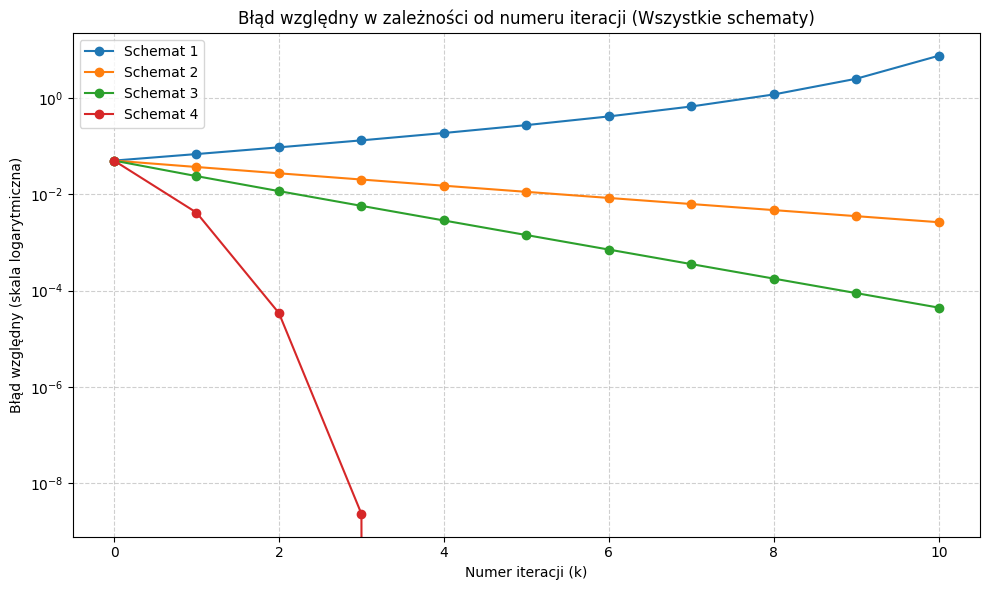

In [29]:
plt.figure(figsize=(10, 6))

for i, errs in rel_errors.items():
    plt.semilogy(range(len(errs)), errs, marker='o', linestyle='-', label=f'Schemat {i}')
    
plt.title('Błąd względny w zależności od numeru iteracji (Wszystkie schematy)')
plt.xlabel('Numer iteracji (k)')
plt.ylabel('Błąd względny (skala logarytmiczna)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

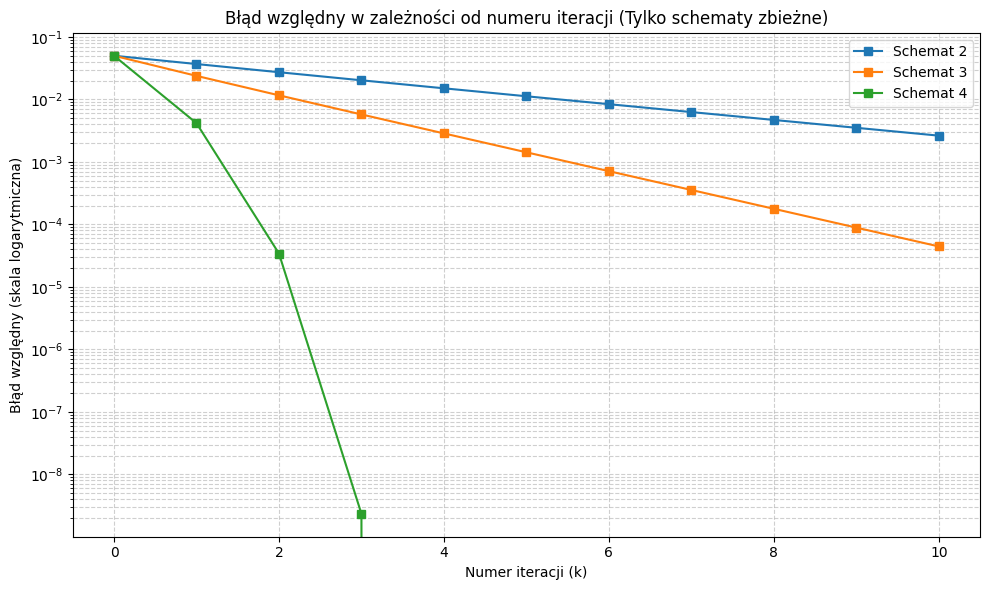

In [30]:
plt.figure(figsize=(10, 6))
convergent_methods = [2, 3, 4]

for i in convergent_methods:
    errs = rel_errors[i]
    plt.semilogy(range(len(errs)), errs, marker='s', linestyle='-', label=f'Schemat {i}')
    
plt.title('Błąd względny w zależności od numeru iteracji (Tylko schematy zbieżne)')
plt.xlabel('Numer iteracji (k)')
plt.ylabel('Błąd względny (skala logarytmiczna)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()